<a href="https://colab.research.google.com/github/PasineeC/hello-zip2025/blob/main/train_miniproject_snakekung.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q fastbook==0.0.29
exit()

In [ ]:
from fastbook import *

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


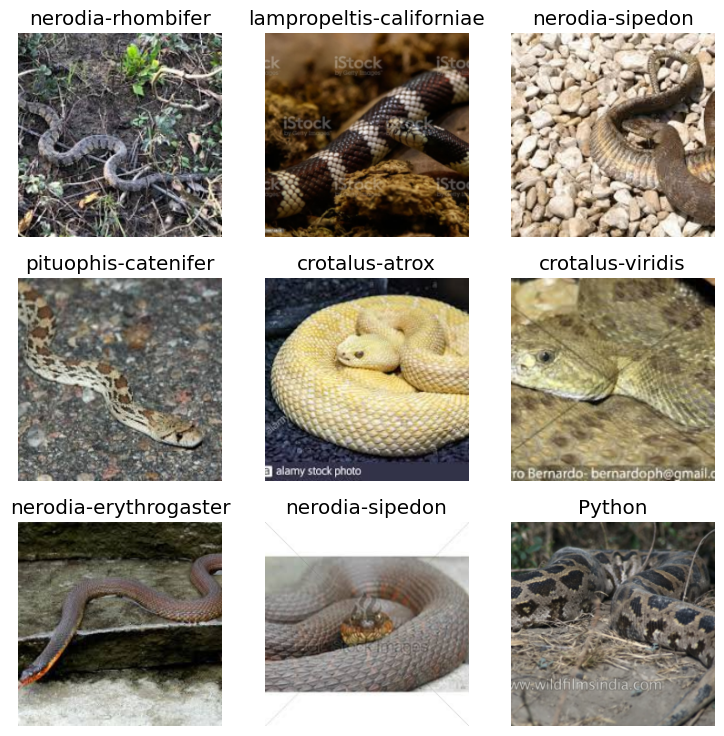

In [ ]:
dblock = DataBlock(blocks    = (ImageBlock, CategoryBlock),
                   get_items = get_image_files,
                   get_y     = parent_label,
                   splitter  = RandomSplitter(),
                   item_tfms = Resize(224))
dls = dblock.dataloaders("/content/drive/MyDrive/งู๊/snakekung")
dls.show_batch()

In [ ]:
learn = cnn_learner(dls, resnet34, metrics = accuracy)
learn.fine_tune(epochs=4, freeze_epochs=1, base_lr=2e-3)

/usr/local/lib/python3.10/dist-packages/fastai/vision/learner.py:288: UserWarning: `cnn_learner` has been renamed to `vision_learner` -- please update your code
  warn("`cnn_learner` has been renamed to `vision_learner` -- please update your code")
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593

epoch,train_loss,valid_loss,accuracy,time
0,2.785952,1.713472,0.497861,1:00:20


epoch,train_loss,valid_loss,accuracy,time
0,1.649329,1.181186,0.642940,1:26:03
1,1.148154,0.930607,0.714119,1:26:36


In [ ]:
learn.save('snakekung')
learn.export('snakekung')

In [ ]:
learn.show_results()

In [ ]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix(figsize = (21,21))